In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor

In [61]:
df = pd.read_csv("jakarta_house.csv")
df.head()

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


In [62]:
df.isna().sum()

index            0
price            0
district         0
city             0
bed_rooms        0
bath_rooms       0
carport          0
land_area        3
building_area    5
dtype: int64

In [63]:
df = df.dropna()
df.isna().sum()

index            0
price            0
district         0
city             0
bed_rooms        0
bath_rooms       0
carport          0
land_area        0
building_area    0
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df.columns

Index(['index', 'price', 'district', 'city', 'bed_rooms', 'bath_rooms',
       'carport', 'land_area', 'building_area'],
      dtype='object')

In [66]:
df.shape

(9992, 9)

In [67]:
df = df.drop('index', axis=1)
df.head()

,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


In [68]:
mapping_kolom = {
    'price': 'Harga',
    'district': 'Kecamatan',
    'city': 'Kota',
    'bed_rooms': 'Kamar Tidur',
    'bath_rooms': 'Kamar Mandi',
    'carport': 'Garasi',
    'land_area': 'Luas Tanah',
    'building_area': 'Luas Bangunan'
}

df = df.rename(columns=mapping_kolom)
df.head()

,Harga,Kecamatan,Kota,Kamar Tidur,Kamar Mandi,Garasi,Luas Tanah,Luas Bangunan
0,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


In [69]:
df.describe()

,Harga,Kamar Tidur,Kamar Mandi,Garasi,Luas Tanah,Luas Bangunan
count,9.992000e+03,9992.000000,9992.000000,9992.000000,9992.000000,9992.000000
mean,1.003935e+10,4.252702,3.521417,1.579363,296.638311,319.919235
std,2.005052e+10,3.176976,2.900295,1.743859,503.038116,357.694301
min,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


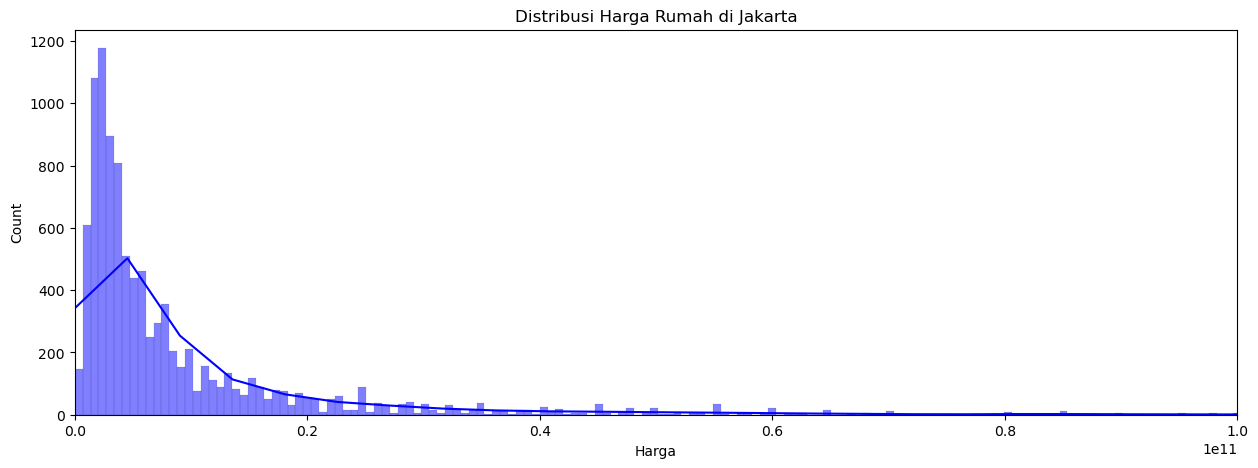

In [70]:
plt.figure(figsize=(15, 5))
sns.histplot(df['Harga'], kde=True, color='blue')
plt.title('Distribusi Harga Rumah di Jakarta')
plt.xlim(0, 100000000000)
plt.show()

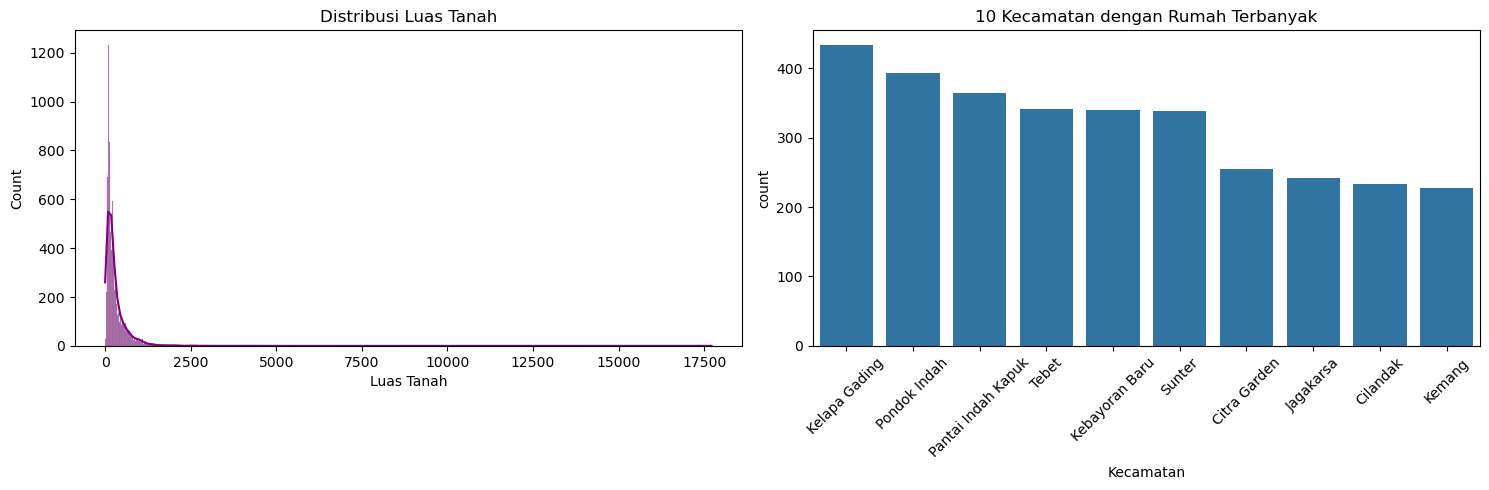

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Luas Tanah'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribusi Luas Tanah')

sns.countplot(x='Kecamatan', data=df, ax=axes[1], order=df['Kecamatan'].value_counts().index[:10])
axes[1].set_title('10 Kecamatan dengan Rumah Terbanyak')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

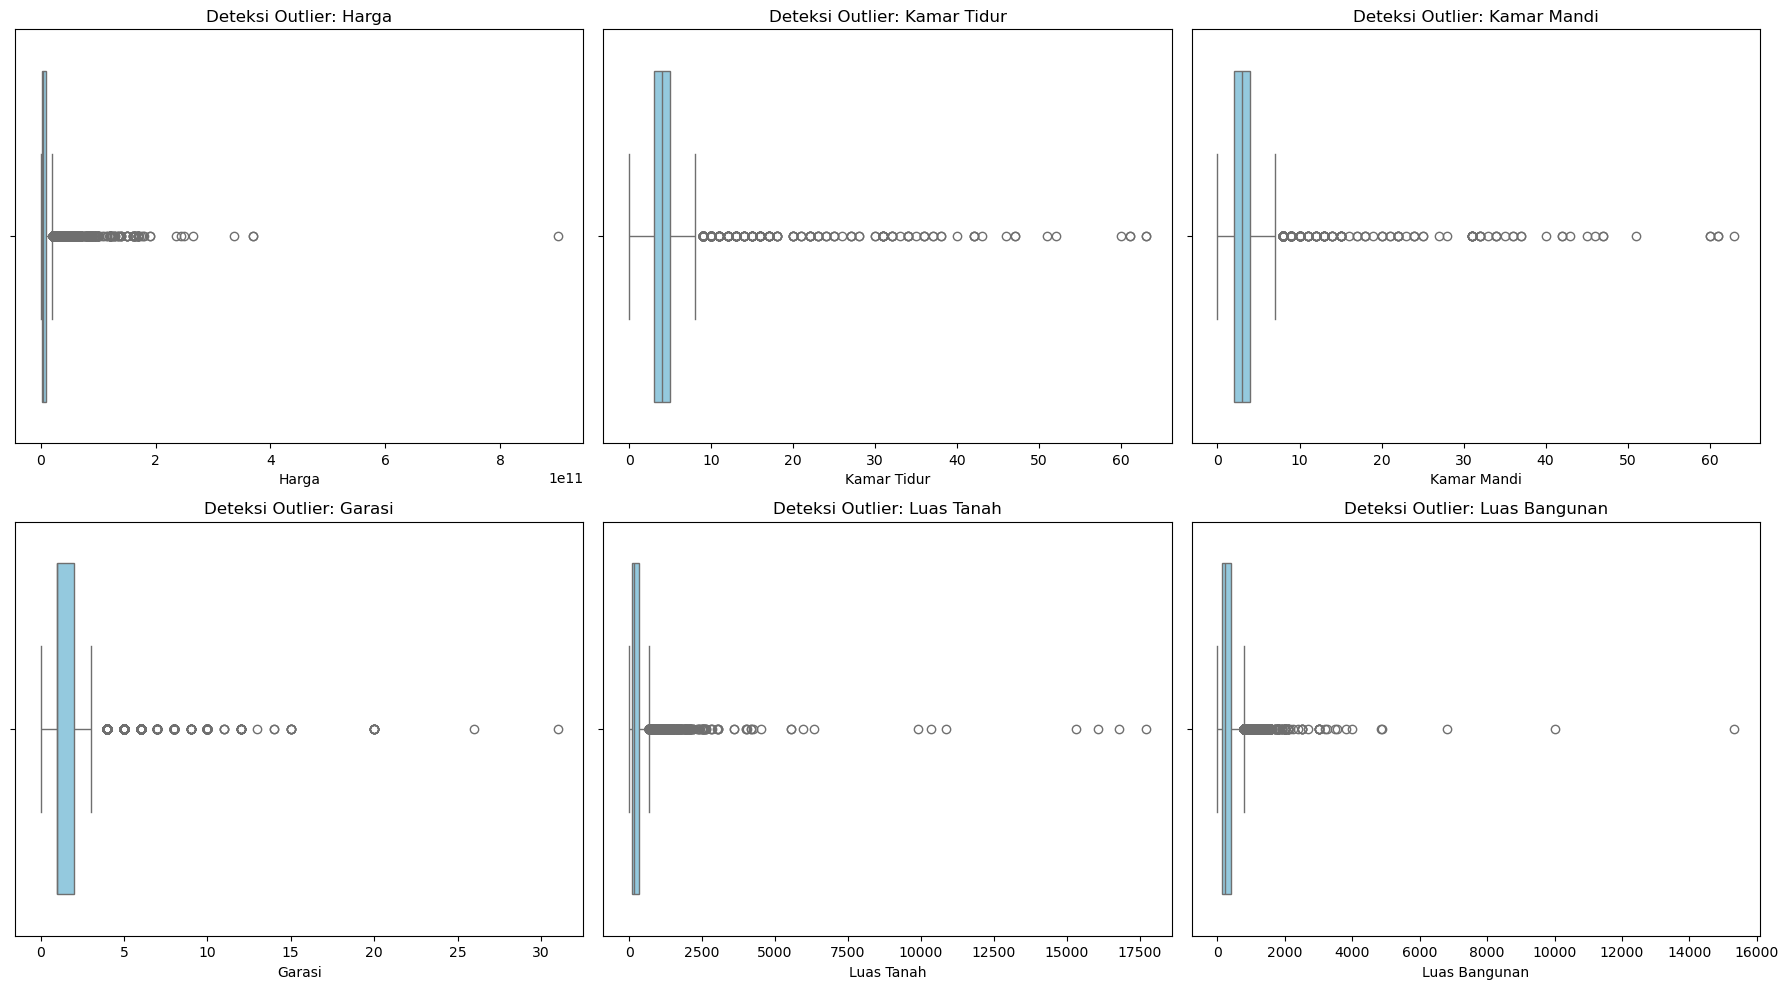

In [72]:
fitur_numerik = df.select_dtypes(include='number')
jumlah_kolom = len(fitur_numerik.columns)

jumlah_baris = (jumlah_kolom // 3) + (1 if jumlah_kolom % 3 > 0 else 0)
fig, axes = plt.subplots(jumlah_baris, 3, figsize=(18, 5 * jumlah_baris))

axes = axes.flatten() 

for i, kolom in enumerate(fitur_numerik.columns):
    sns.boxplot(x=df[kolom], ax=axes[i], color='skyblue') 
    axes[i].set_title(f'Deteksi Outlier: {kolom}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [73]:
df_bersih = df.copy()

fitur_numerik = df_bersih.select_dtypes(include='number').columns

for kolom in fitur_numerik:
    Q1 = df_bersih[kolom].quantile(0.25)
    Q3 = df_bersih[kolom].quantile(0.75)
    
    IQR = Q3 - Q1
    
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    df_bersih = df_bersih[(df_bersih[kolom] >= batas_bawah) & (df_bersih[kolom] <= batas_atas)]

print(f"Jumlah data SEBELUM dihapus outlier: {len(df)} baris")
print(f"Jumlah data SETELAH dihapus outlier: {len(df_bersih)} baris")

Jumlah data SEBELUM dihapus outlier: 9992 baris
Jumlah data SETELAH dihapus outlier: 7523 baris


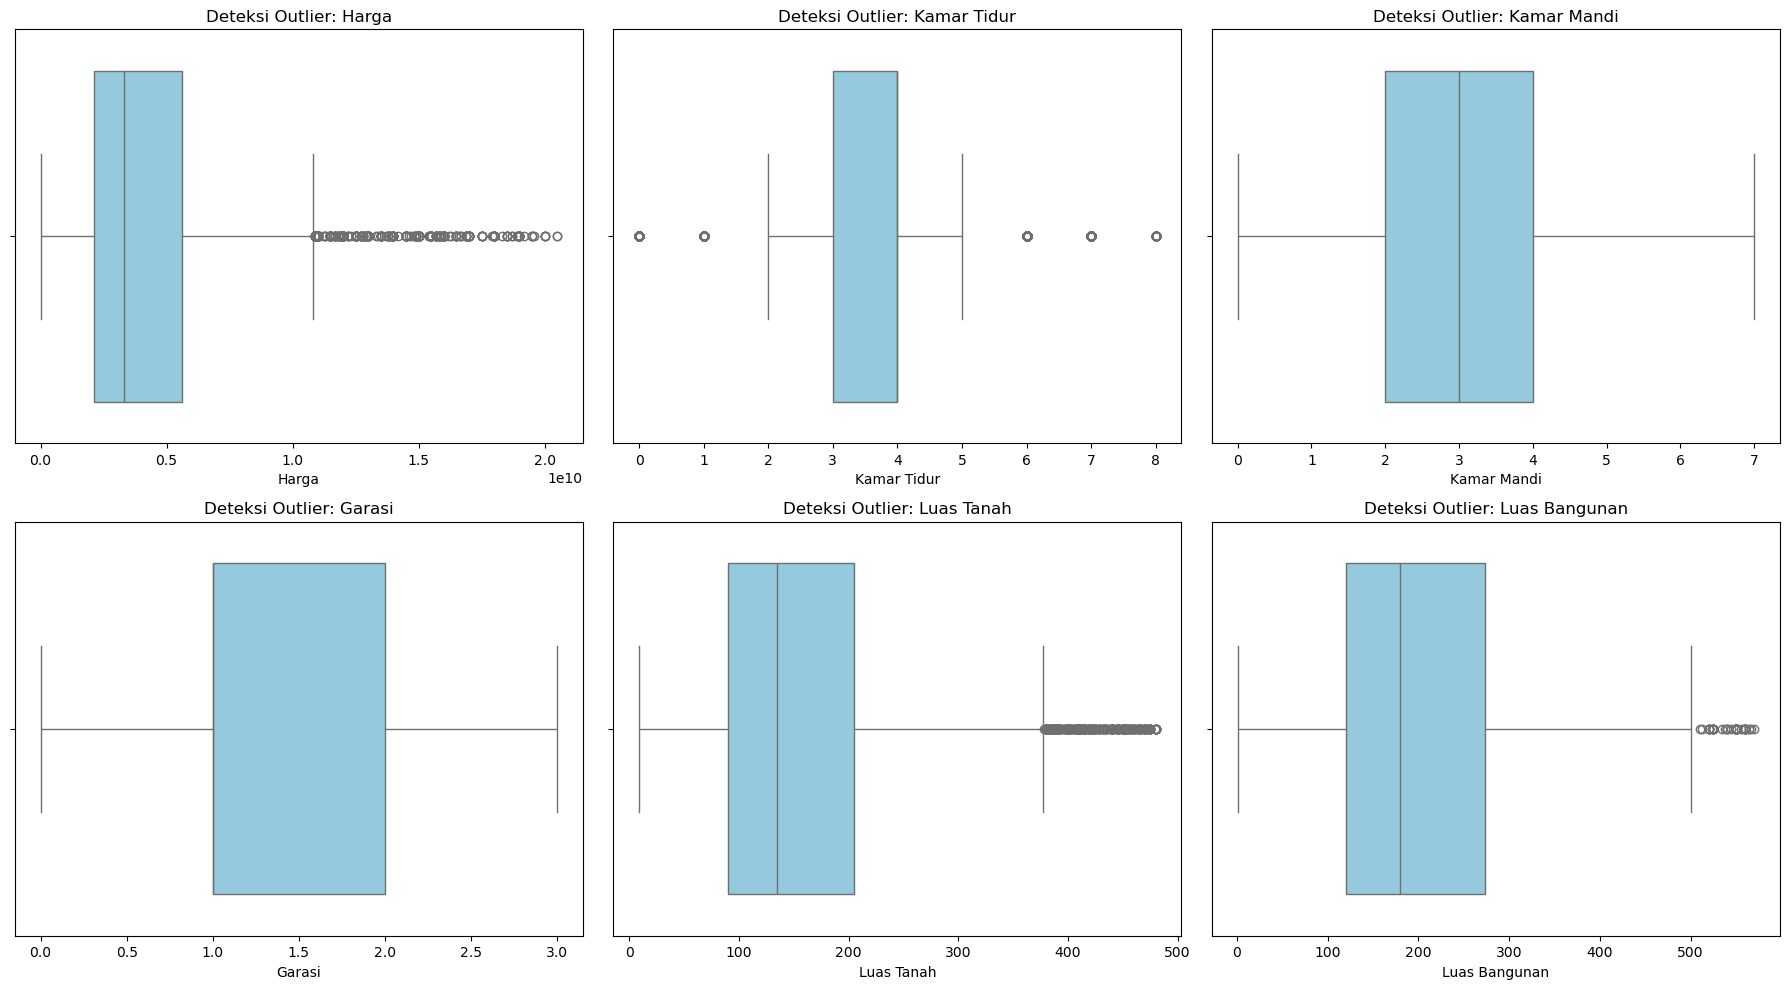

In [74]:
fitur_numerik = df_bersih.select_dtypes(include='number')
jumlah_kolom = len(fitur_numerik.columns)

jumlah_baris = (jumlah_kolom // 3) + (1 if jumlah_kolom % 3 > 0 else 0)
fig, axes = plt.subplots(jumlah_baris, 3, figsize=(18, 5 * jumlah_baris))

axes = axes.flatten() 

for i, kolom in enumerate(fitur_numerik.columns):
    sns.boxplot(x=df_bersih[kolom], ax=axes[i], color='skyblue') 
    axes[i].set_title(f'Deteksi Outlier: {kolom}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [75]:
df_bersih.columns

Index(['Harga', 'Kecamatan', 'Kota', 'Kamar Tidur', 'Kamar Mandi', 'Garasi',
       'Luas Tanah', 'Luas Bangunan'],
      dtype='object')

In [76]:
df_bersih['Harga_Log'] = np.log1p(df_bersih['Harga'])
df_bersih = df_bersih.drop('Harga', axis=1)

In [77]:
if 'Kota' in df_bersih.columns:
    df_bersih = df_bersih.drop('Kota', axis=1)

df_model = pd.get_dummies(df_bersih, columns=['Kecamatan'], drop_first=True)

In [78]:
y = df_model['Harga_Log']

X = df_model.drop('Harga_Log', axis=1)

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data belajar: {X_train.shape[0]} rumah")
print(f"Jumlah data ujian: {X_test.shape[0]} rumah")

Jumlah data belajar: 6018 rumah
Jumlah data ujian: 1505 rumah


In [80]:
y_test_asli = np.expm1(y_test)

# Masukkan model baru ke dalam dictionary
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1) # verbose=-1 agar teks loadingnya tidak nyepam
}

# Dictionary untuk menyimpan hasil
hasil_evaluasi = {}

# Looping tetap sama persis seperti buatanmu
for nama_model, model in models.items():
    model.fit(X_train, y_train)
    
    prediksi_log = model.predict(X_test)
    prediksi_asli = np.expm1(prediksi_log)
    
    mae = mean_absolute_error(y_test_asli, prediksi_asli)
    rmse = np.sqrt(mean_squared_error(y_test_asli, prediksi_asli))
    r2 = r2_score(y_test_asli, prediksi_asli)
    
    hasil_evaluasi[nama_model] = {
        'MAE (Rp)': f"Rp {mae:,.0f}",
        'RMSE (Rp)': f"Rp {rmse:,.0f}",
        'R-Squared': f"{r2:.4f}"
    }

# Menampilkan tabel hasil
df_hasil = pd.DataFrame(hasil_evaluasi).T
display(df_hasil)

,MAE (Rp),RMSE (Rp),R-Squared
Linear Regression,"Rp 1,055,240,763","Rp 1,853,906,461",0.6910
Ridge Regression,"Rp 1,050,658,635","Rp 1,784,127,587",0.7138
KNN,"Rp 1,227,788,440","Rp 2,052,755,788",0.6211
Random Forest,"Rp 890,701,076","Rp 1,544,332,551",0.7856
XGBoost,"Rp 904,557,265","Rp 1,513,802,740",0.7940
LightGBM,"Rp 967,226,604","Rp 1,657,009,940",0.7531


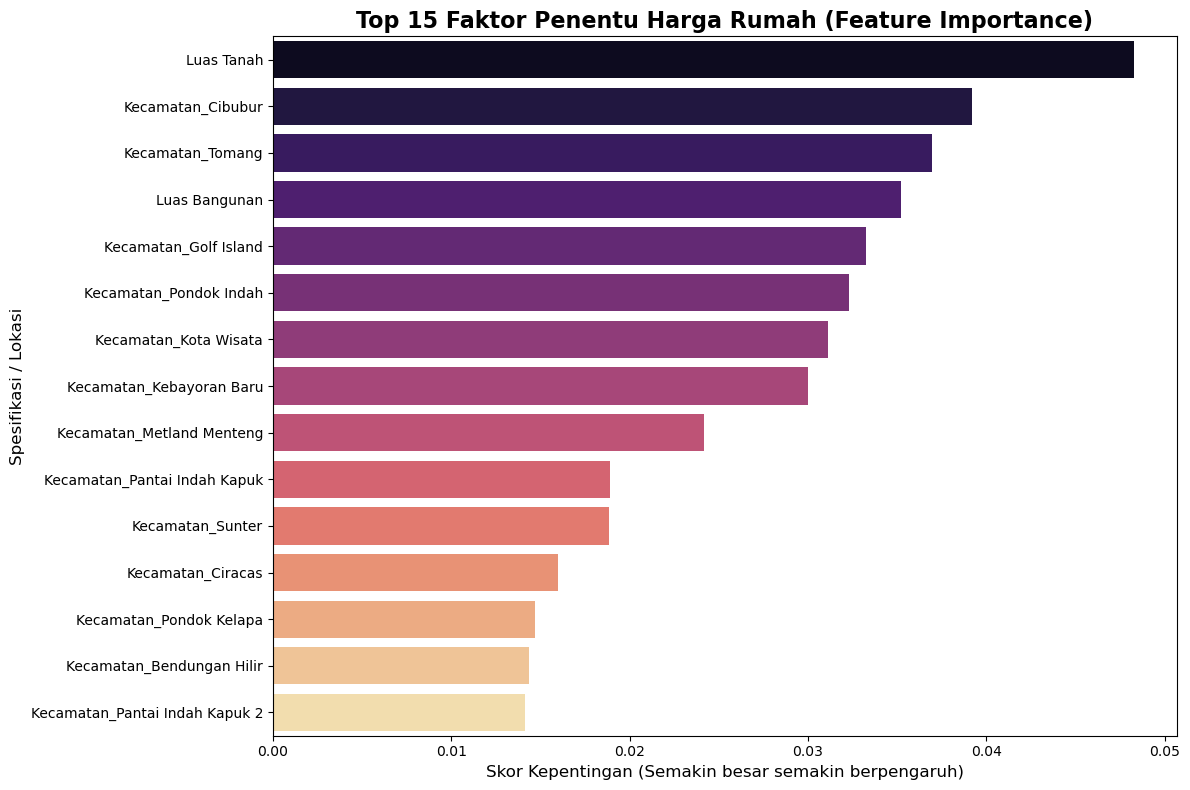

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_pilihan = models['XGBoost'] 

importances = model_pilihan.feature_importances_

df_importance = pd.DataFrame({
    'Fitur': X_train.columns,
    'Tingkat Kepentingan': importances
})

df_importance = df_importance.sort_values(by='Tingkat Kepentingan', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=df_importance.head(15), palette='magma', hue='Fitur')

plt.title('Top 15 Faktor Penentu Harga Rumah (Feature Importance)', fontsize=16, fontweight='bold')
plt.xlabel('Skor Kepentingan (Semakin besar semakin berpengaruh)', fontsize=12)
plt.ylabel('Spesifikasi / Lokasi', fontsize=12)
plt.tight_layout()
plt.show()

In [83]:
import joblib

# Simpan model terbaik (Linear Regression)
joblib.dump(models['XGBoost'], 'model_rumah_uika.pkl')

# Simpan daftar kolom agar One-Hot Encoding-nya tidak tertukar
joblib.dump(X.columns.tolist(), 'daftar_kolom.pkl')

print("Model dan Kolom berhasil disimpan!")

Model dan Kolom berhasil disimpan!


In [84]:
# Cek rumah harga di bawah 1 Miliar
rumah_murah = df[df['Harga'] < 1000000000]
print(f"Jumlah rumah di bawah 1 M: {len(rumah_murah)}")

Jumlah rumah di bawah 1 M: 433
